# MMP-9 Bioactivity Classification: Model Training, Evaluation & Mechanistic Analysis

**Target:** Matrix Metalloproteinase-9 (MMP-9) — ChEMBL ID: CHEMBL321  
**Task:** Binary classification of compounds as Active (pIC50 ≥ 5.3) or Inactive  
**Fingerprint:** Morgan/ECFP4 (radius=2, 2048 bits)  
**Split strategy:** Murcko Scaffold split (no scaffold overlap between train/test)

---

## Notebook Structure

| Section | What happens | Why it matters |
|---------|-------------|----------------|
| 1 | Data loading | Sanity check on split integrity |
| 2 | Baseline models | Establish floor before optimization |
| 3 | Champion model + threshold tuning | Maximize MCC on unseen data |
| 4 | Performance comparison | Quantify gains from each design decision |
| 5 | Feature importance + chemical visualization | Understand *what* the model learned |
| 6 | Warhead bias analysis | Characterize a systematic model blind spot |
| 7 | Ablation experiments | Test three hypotheses about the bias |
| 8 | Explicit warhead feature | Make hidden signal transparent |
| 9 | Serialization | Save model for virtual screening |
| 10 | Conclusion & limitations | Motivate transition to ChemBERTa |


## 1. Imports

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_predict
import xgboost as xgb

from rdkit import Chem
from rdkit.Chem import Draw, rdFingerprintGenerator
from rdkit.Chem import MolFromSmarts
from IPython.display import display

print('Libraries loaded.')

Libraries loaded.


## 2. Load Model-Ready Data

We load the `.npz` archive produced by the feature engineering notebook. It contains:

- **Train split:** SMOTE-balanced Morgan fingerprints — the model learns from this.
- **Test split:** Untouched, scaffold-separated, class-imbalanced — this is our honest evaluation.
- **SMILES arrays:** Retained alongside fingerprints so we can map predictions back to structures for interpretability.

> **Why scaffold split?** Random splitting would allow structurally similar compounds to leak between train and test, inflating MCC artificially. Murcko scaffold splitting enforces that the model is tested on genuinely novel chemical scaffolds — a more realistic proxy for drug discovery deployment.

In [105]:
data_path = '../data/processed/mmp9_model_ready_splits.npz'
data = np.load(data_path, allow_pickle=True)

X_train      = data['X_train']
y_train      = data['y_train']
X_test       = data['X_test']
y_test       = data['y_test']
smiles_train = data['smiles_train']
smiles_test  = data['smiles_test']

print(f'Train: {X_train.shape} features | {y_train.sum()} actives / {(y_train==0).sum()} inactives')
print(f'Test:  {X_test.shape} features  | {y_test.sum()} actives / {(y_test==0).sum()} inactives')
print(f'\nNote: Train is SMOTE-balanced. Test reflects real-world class imbalance ({y_test.mean()*100:.1f}% active).')

Train: (1141, 2048) features | 1002 actives / 139 inactives
Test:  (285, 2048) features  | 225 actives / 60 inactives

Note: Train is SMOTE-balanced. Test reflects real-world class imbalance (78.9% active).


## 3. Baseline Models

Before any optimization, we establish a performance floor using default hyperparameters and a fixed 0.5 decision threshold. This baseline is essential — without it, we cannot claim that our optimizations actually added value rather than just adding complexity.

Both models use class-imbalance handling:
- RF: `class_weight='balanced'`
- XGBoost: `scale_pos_weight` = ratio of negatives to positives in training set

**Metric:** Matthews Correlation Coefficient (MCC). Chosen over accuracy or F1 because MCC accounts for all four quadrants of the confusion matrix simultaneously and is robust to class imbalance — critical when our test set has ~86% actives.

In [106]:
print('Training Baseline Random Forest...')
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_base.fit(X_train, y_train)
mcc_rf_base = matthews_corrcoef(y_test, rf_base.predict(X_test))
print(f'  RF Baseline MCC: {mcc_rf_base:.4f}')

print('Training Baseline XGBoost...')
scale_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb_base = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    scale_pos_weight=scale_weight, random_state=42, n_jobs=-1
)
xgb_base.fit(X_train, y_train)
mcc_xgb_base = matthews_corrcoef(y_test, xgb_base.predict(X_test))
print(f'  XGBoost Baseline MCC: {mcc_xgb_base:.4f}')

Training Baseline Random Forest...
  RF Baseline MCC: 0.6983
Training Baseline XGBoost...
  XGBoost Baseline MCC: 0.5894


## 4. Champion Model: Optimized RF + Threshold Tuning

Random Forest outperformed XGBoost on our sparse, binary 2048-bit Morgan fingerprint data. This is expected — RF handles high-dimensional sparse binary features well because each tree only sees a random subset of bits (`max_features='sqrt'`), preventing any single dominant bit from monopolizing every split.

**Threshold optimization rationale:**  
The default 0.5 threshold treats false positives and false negatives as equally costly. In early-stage drug discovery, missing a true active (false negative) is typically more costly than investigating a false positive. Lowering the threshold to 0.4417 shifts the model slightly toward sensitivity without collapsing specificity — and MCC mathematically penalizes both, so we use it as the optimization target.

Threshold is found via 5-fold cross-validation on training data to avoid test set leakage.

In [107]:
print('Training Champion Random Forest...')
rf_champ = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=40,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Find optimal threshold via cross-validation — never touch the test set here
print('Calculating optimal decision threshold via 5-fold CV...')
y_train_proba = cross_val_predict(
    rf_champ, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]

thresholds = np.linspace(0.1, 0.9, 100)
mcc_scores = [matthews_corrcoef(y_train, (y_train_proba >= t).astype(int)) for t in thresholds]

optimal_threshold = thresholds[np.argmax(mcc_scores)]
print(f'Optimal threshold: {optimal_threshold:.4f} (CV MCC: {max(mcc_scores):.4f})')

# Train on full training set, evaluate on untouched test set
rf_champ.fit(X_train, y_train)
y_proba_champ = rf_champ.predict_proba(X_test)[:, 1]
y_pred_champ  = (y_proba_champ >= optimal_threshold).astype(int)
mcc_champ     = matthews_corrcoef(y_test, y_pred_champ)

print(f'\nChampion Model — Test MCC: {mcc_champ:.4f}')
print('Confusion Matrix:')
cm = confusion_matrix(y_test, y_pred_champ)
print(f'  TN: {cm[0,0]}  FP: {cm[0,1]}')
print(f'  FN: {cm[1,0]}  TP: {cm[1,1]}')

Training Champion Random Forest...
Calculating optimal decision threshold via 5-fold CV...
Optimal threshold: 0.4313 (CV MCC: 0.5879)

Champion Model — Test MCC: 0.6845
Confusion Matrix:
  TN: 34  FP: 26
  FN: 2  TP: 223


## 5. Performance Comparison

Visual summary of MCC gains from baseline → champion. Each design decision (hyperparameter tuning, threshold optimization) contributes incrementally.

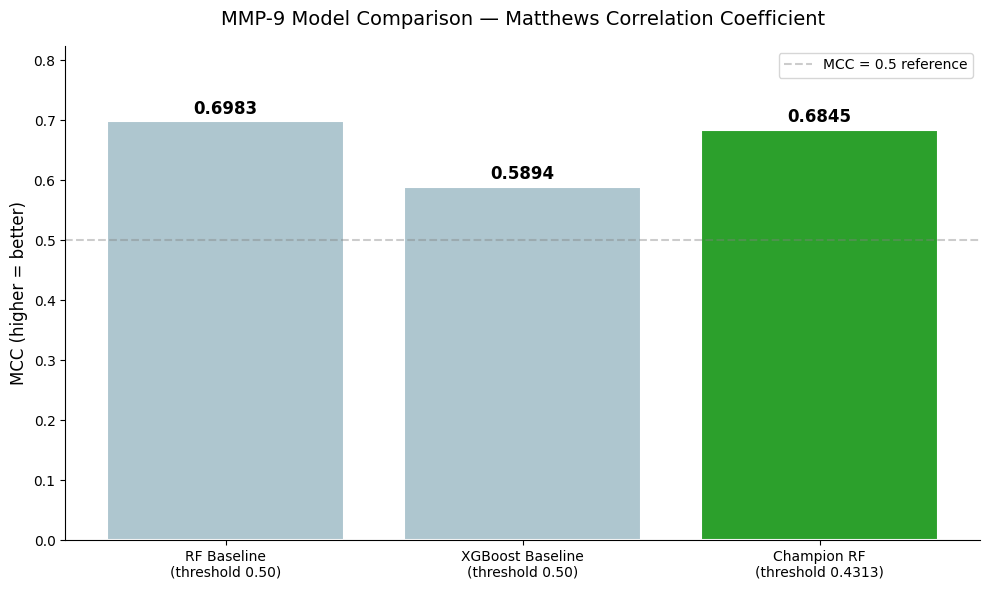

In [108]:
models     = ['RF Baseline\n(threshold 0.50)', 'XGBoost Baseline\n(threshold 0.50)', f'Champion RF\n(threshold {optimal_threshold:.4f})']
mcc_values = [mcc_rf_base, mcc_xgb_base, mcc_champ]
colors     = ['#aec6cf', '#aec6cf', '#2ca02c']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, mcc_values, color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, mcc_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.012,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)

ax.set_title('MMP-9 Model Comparison — Matthews Correlation Coefficient', fontsize=14, pad=15)
ax.set_ylabel('MCC (higher = better)', fontsize=12)
ax.set_ylim(0, max(mcc_values) * 1.18)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='MCC = 0.5 reference')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## 6. Feature Importance & Chemical Visualization

Random Forest assigns an importance score to each of the 2048 Morgan bits based on how much each bit reduces impurity (Gini) across all trees. We visualize the top 20 bits and then inspect their chemical meaning.

For each of the top 20 confident test predictions, we draw the molecule and highlight which of the top-20 bits are present in it. This makes model reasoning chemically interpretable — you can see *which substructures* drove each prediction.

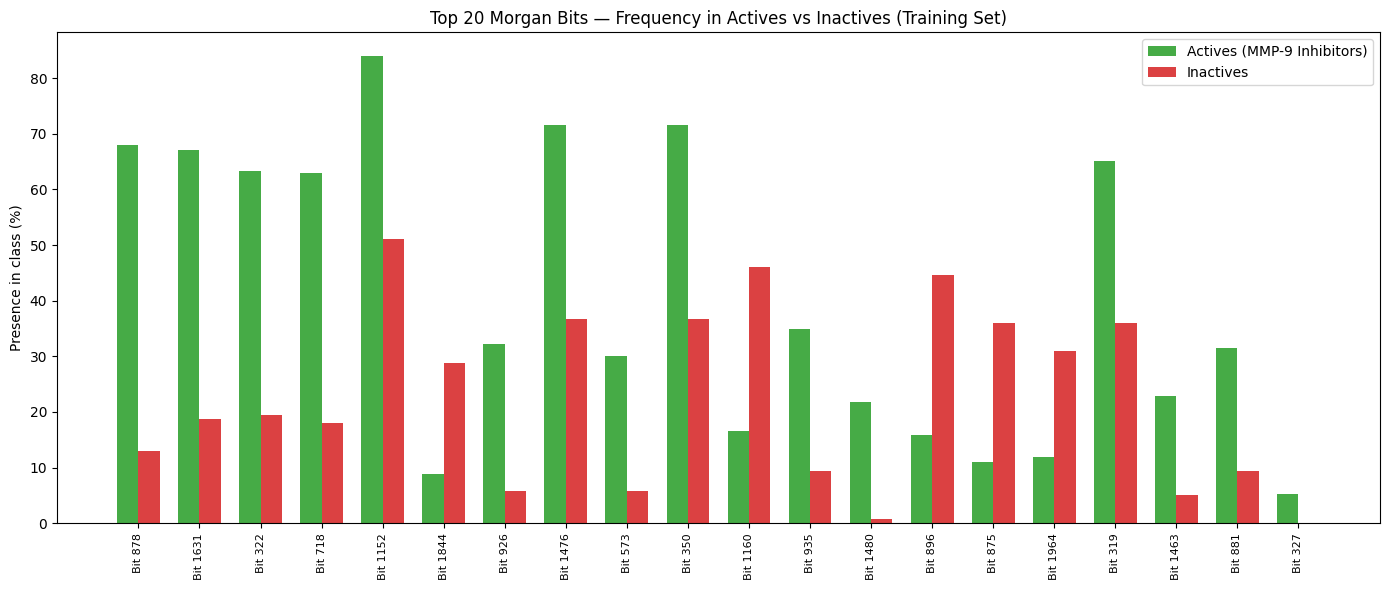

Top bit: 878 | Importance: 0.0383
Active freq: 68.0%  |  Inactive freq: 12.9%


In [109]:
importances     = rf_champ.feature_importances_
top_20_indices  = np.argsort(importances)[-20:][::-1]
top_20_scores   = importances[top_20_indices]

actives_mask   = (y_train == 1)
inactives_mask = (y_train == 0)

active_freqs   = [np.mean(X_train[actives_mask,   bit]) * 100 for bit in top_20_indices]
inactive_freqs = [np.mean(X_train[inactives_mask, bit]) * 100 for bit in top_20_indices]

x = np.arange(len(top_20_indices))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, active_freqs,   width, label='Actives (MMP-9 Inhibitors)', color='#2ca02c', alpha=0.88)
ax.bar(x + width/2, inactive_freqs, width, label='Inactives',                  color='#d62728', alpha=0.88)

ax.set_ylabel('Presence in class (%)')
ax.set_title('Top 20 Morgan Bits — Frequency in Actives vs Inactives (Training Set)')
ax.set_xticks(x)
ax.set_xticklabels([f'Bit {b}' for b in top_20_indices], rotation=90, fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Top bit: {top_20_indices[0]} | Importance: {top_20_scores[0]:.4f}')
print(f'Active freq: {active_freqs[0]:.1f}%  |  Inactive freq: {inactive_freqs[0]:.1f}%')

=== TOP CONFIDENT ACTIVES ===

Active mol 1 — 11/20 important bits present:


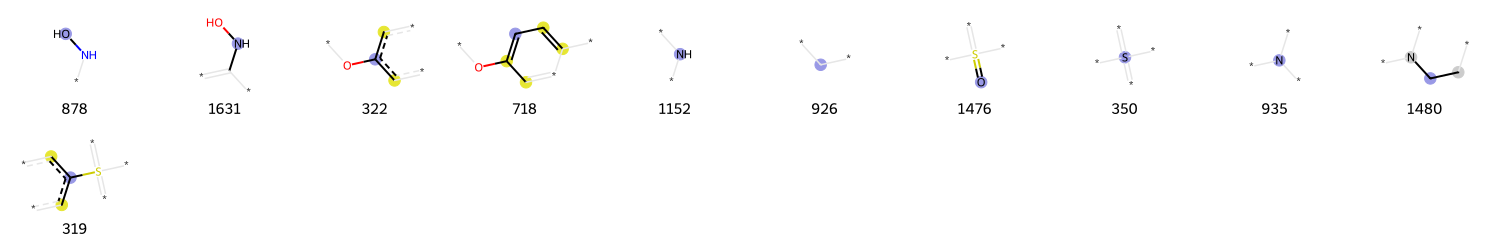


Active mol 2 — 11/20 important bits present:


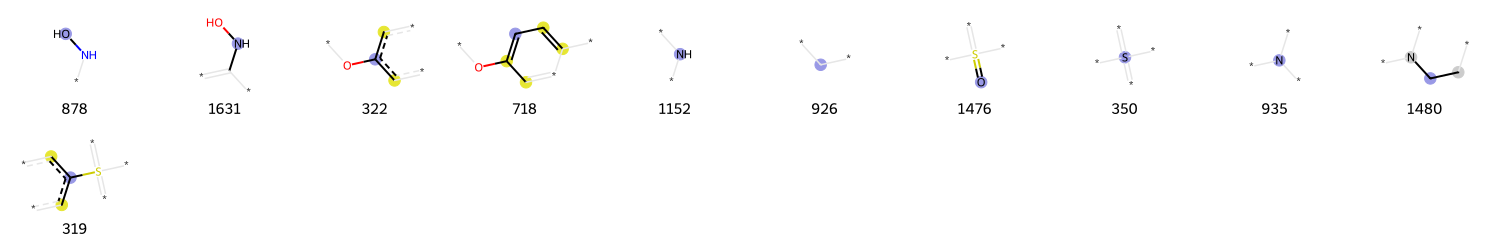


Active mol 3 — 11/20 important bits present:


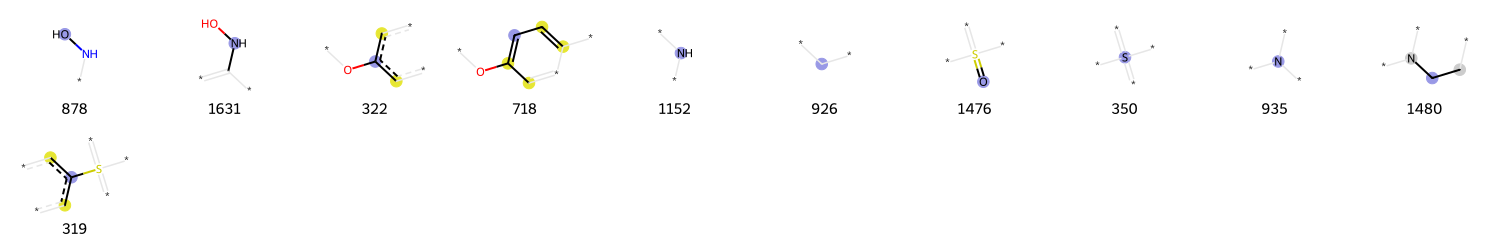


Active mol 4 — 11/20 important bits present:


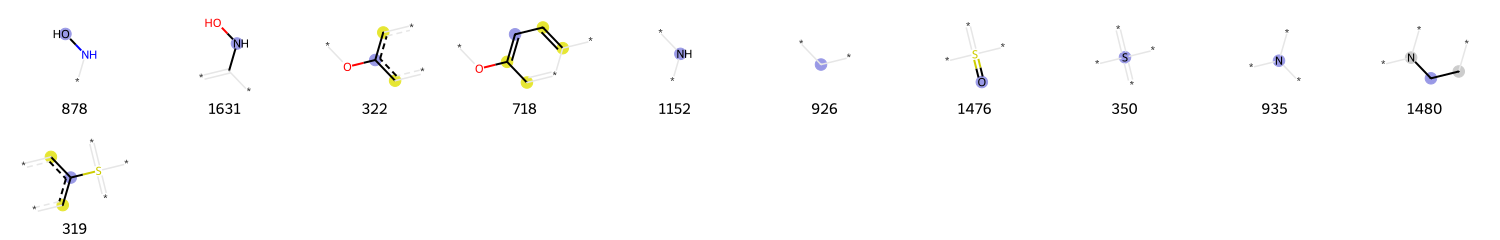


Active mol 5 — 10/20 important bits present:


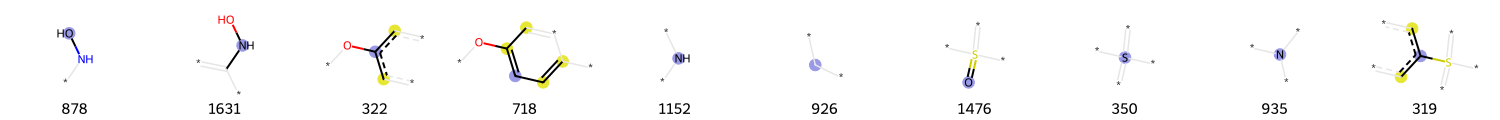


Active mol 6 — 10/20 important bits present:


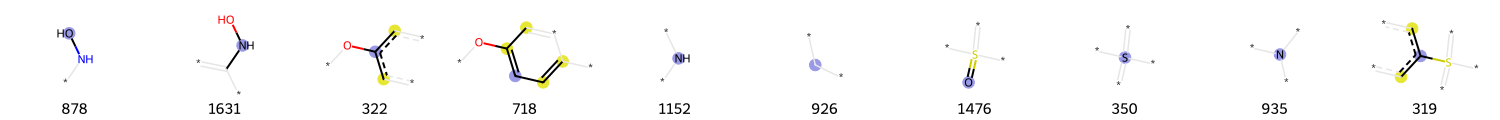


Active mol 7 — 11/20 important bits present:


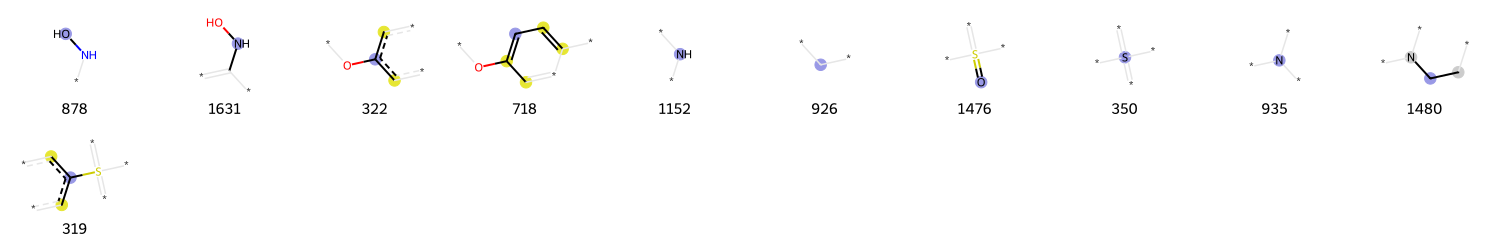


Active mol 8 — 11/20 important bits present:


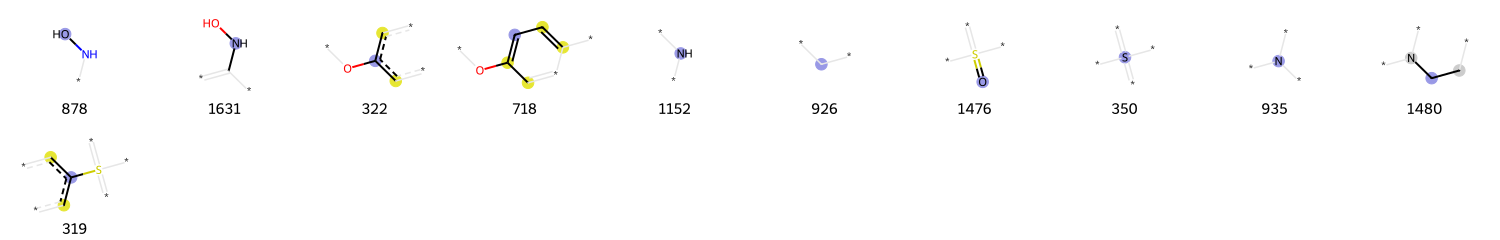


Active mol 9 — 11/20 important bits present:


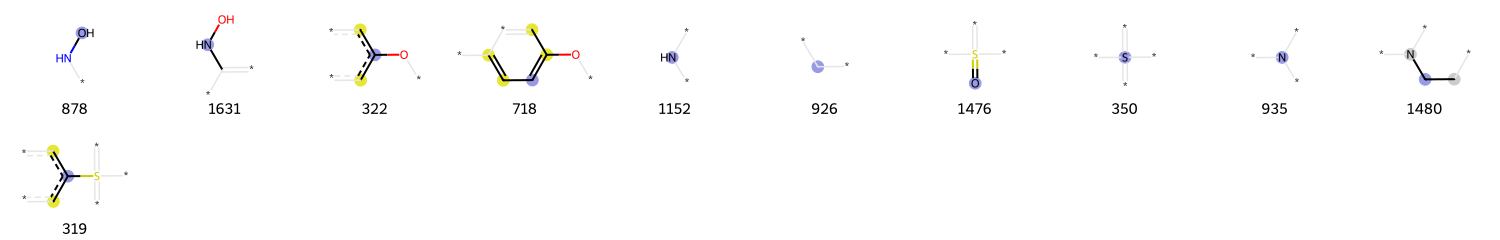


Active mol 10 — 12/20 important bits present:


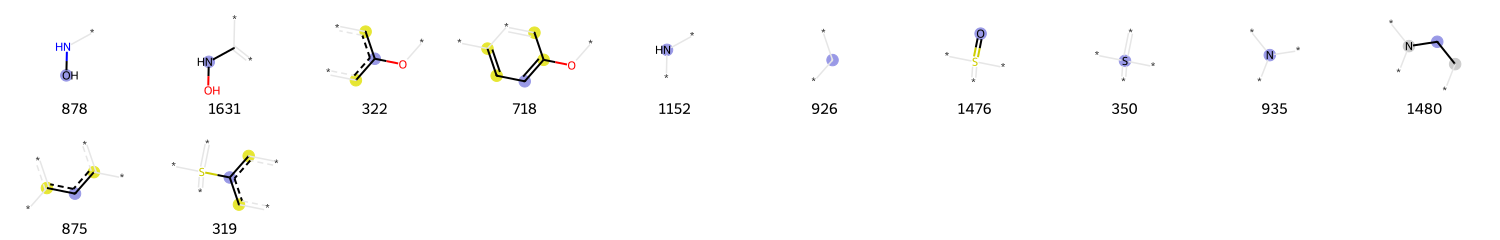


Active mol 11 — 11/20 important bits present:


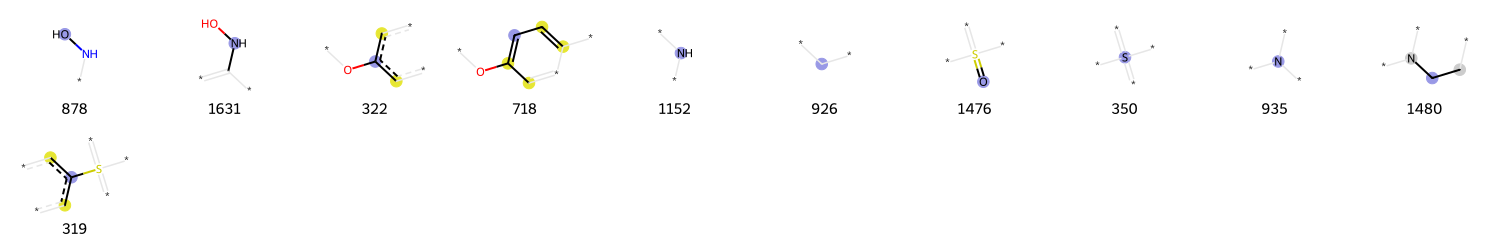


Active mol 12 — 10/20 important bits present:


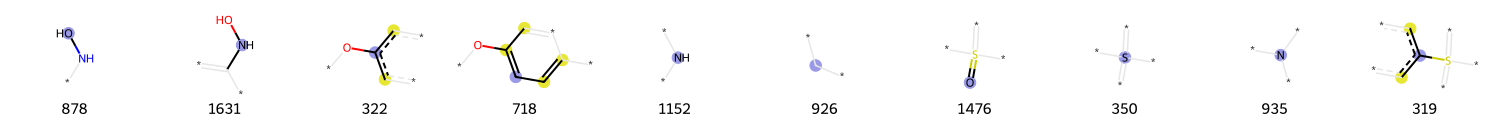


Active mol 13 — 11/20 important bits present:


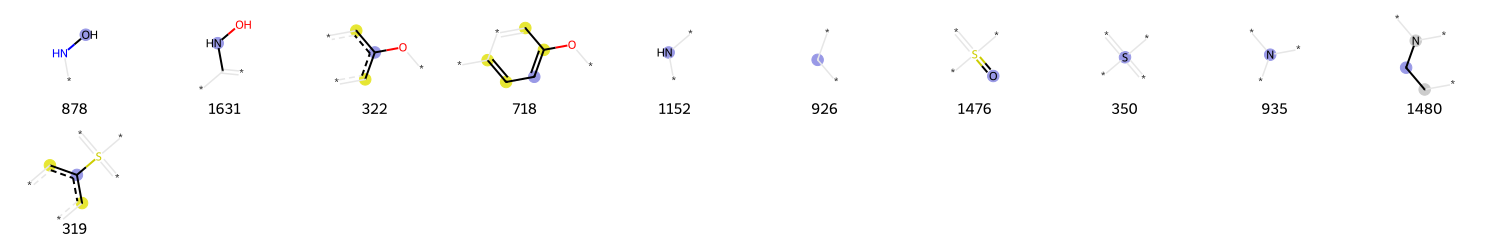


Active mol 14 — 10/20 important bits present:


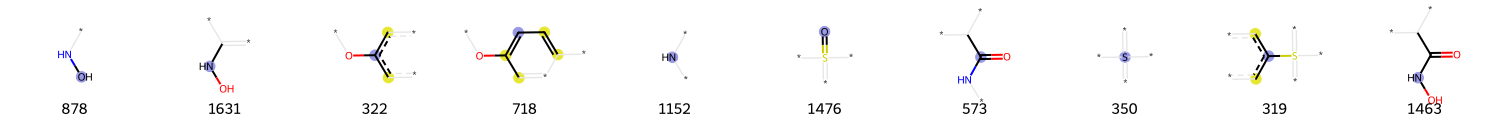


Active mol 15 — 11/20 important bits present:


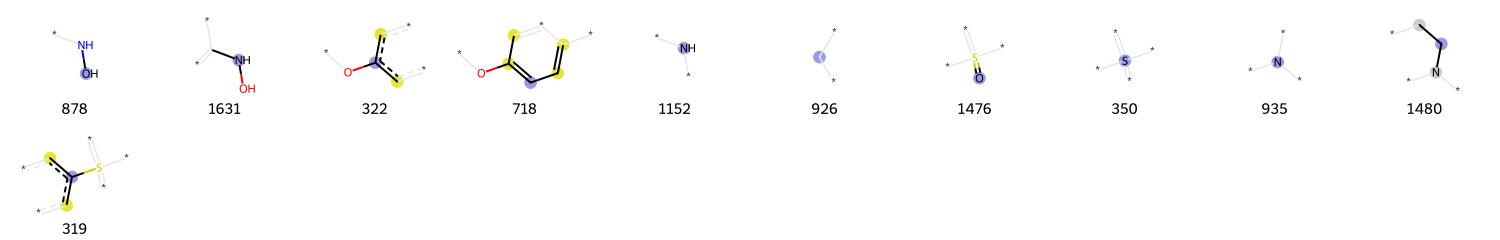


Active mol 16 — 11/20 important bits present:


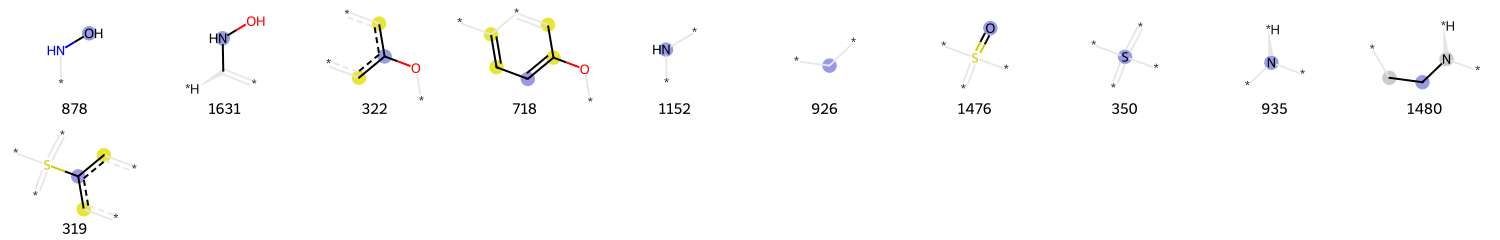


Active mol 17 — 11/20 important bits present:


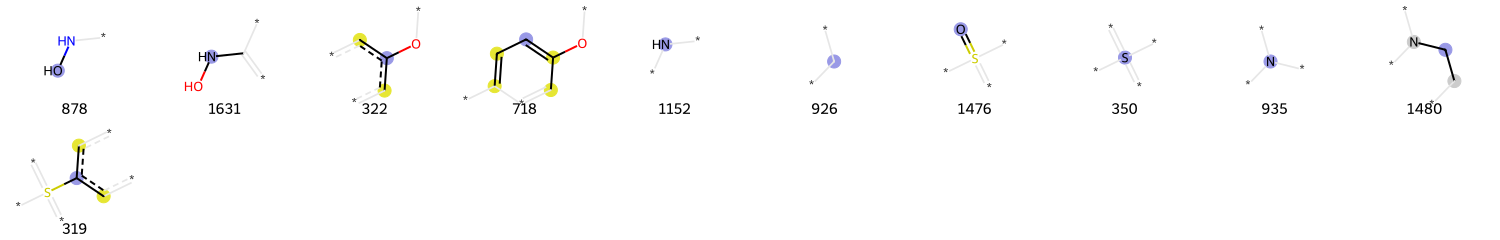


Active mol 18 — 11/20 important bits present:


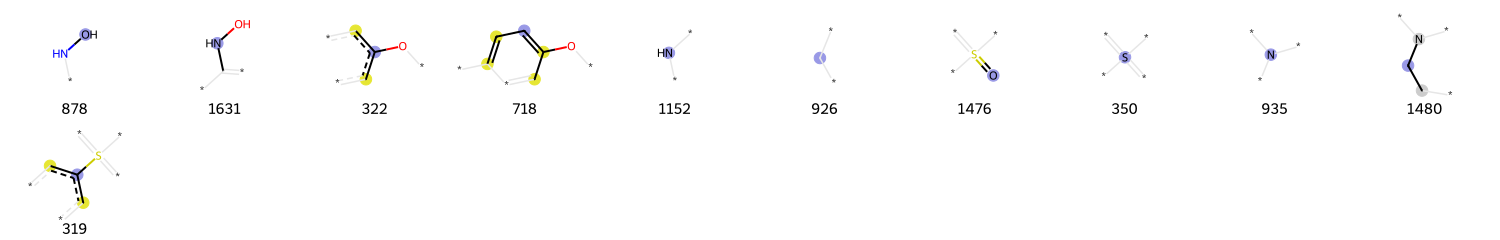


Active mol 19 — 11/20 important bits present:


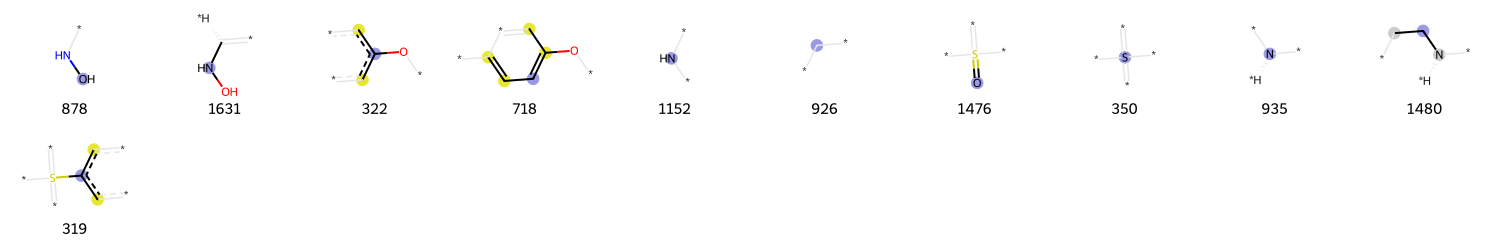


Active mol 20 — 10/20 important bits present:


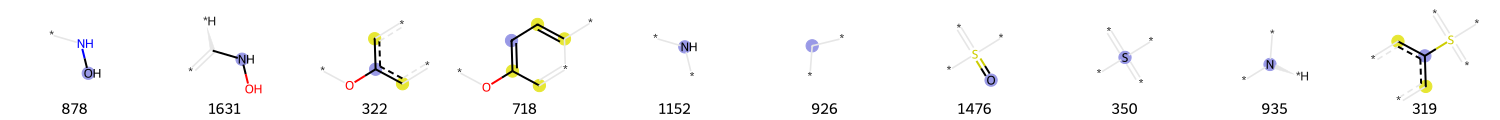


=== TOP CONFIDENT INACTIVES ===

Inactive mol 4 — 1/20 important bits present:


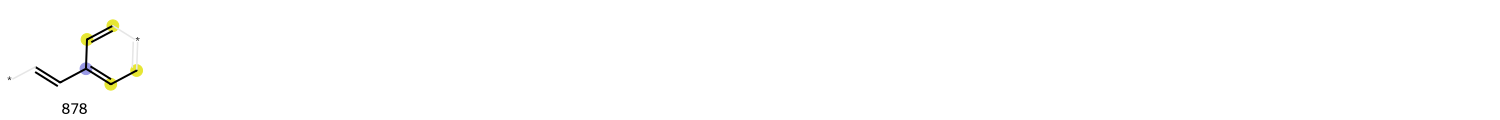


Inactive mol 5 — 3/20 important bits present:


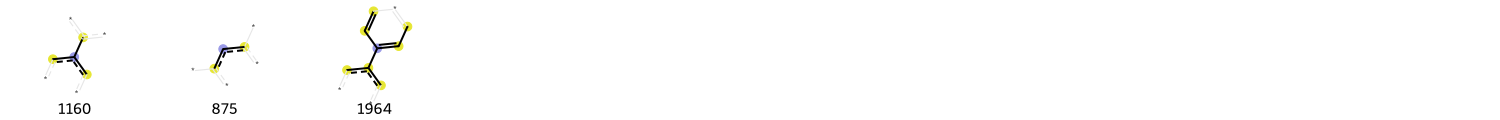


Inactive mol 6 — 1/20 important bits present:


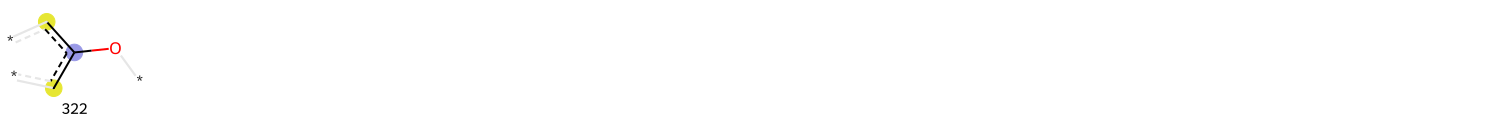


Inactive mol 8 — 2/20 important bits present:


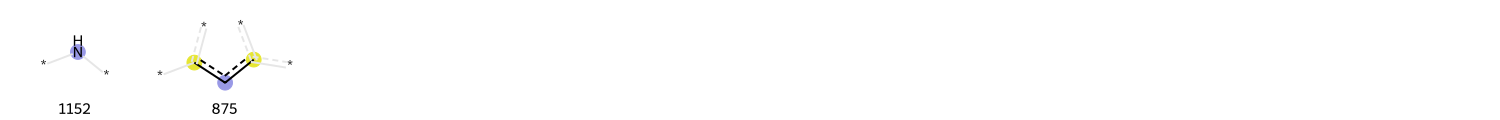


Inactive mol 9 — 4/20 important bits present:


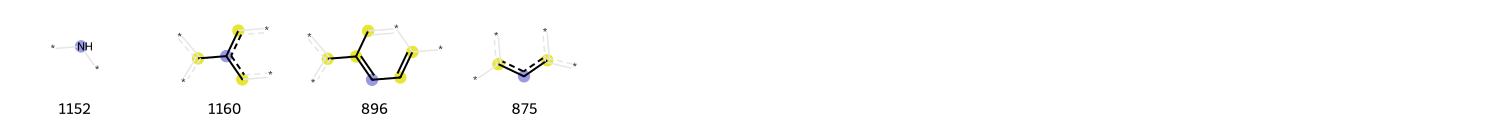


Inactive mol 10 — 1/20 important bits present:


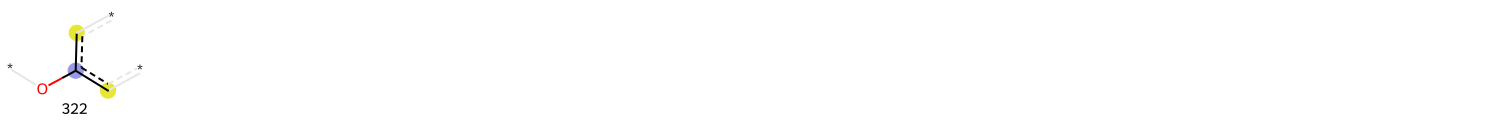


Inactive mol 11 — 3/20 important bits present:


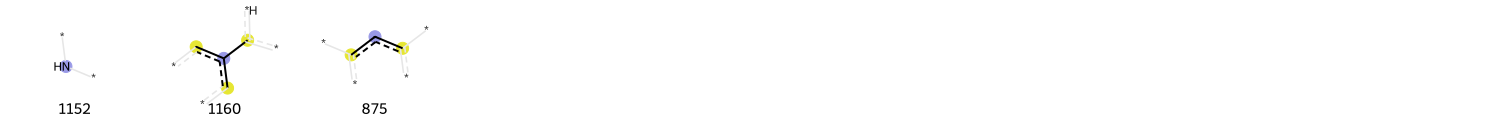


Inactive mol 12 — 1/20 important bits present:


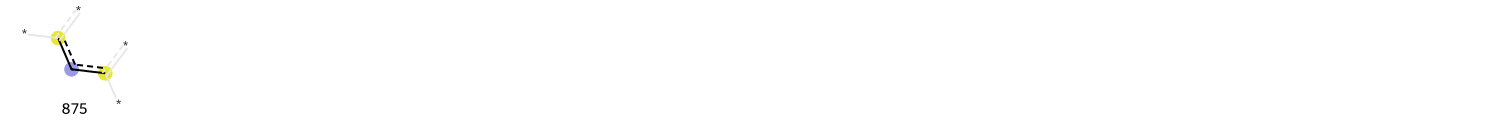


Inactive mol 13 — 2/20 important bits present:


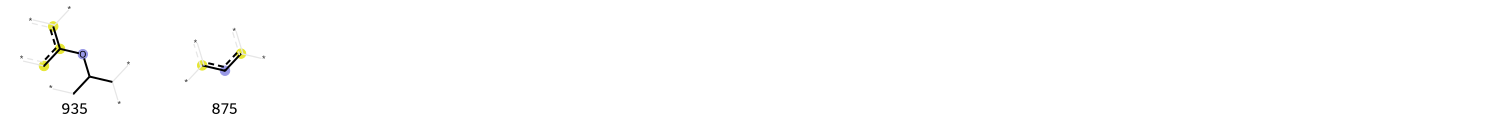


Inactive mol 14 — 3/20 important bits present:


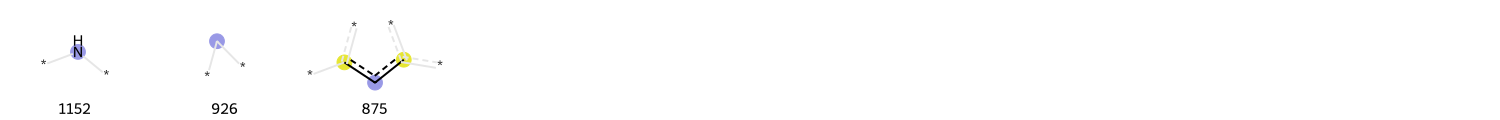


Inactive mol 15 — 1/20 important bits present:


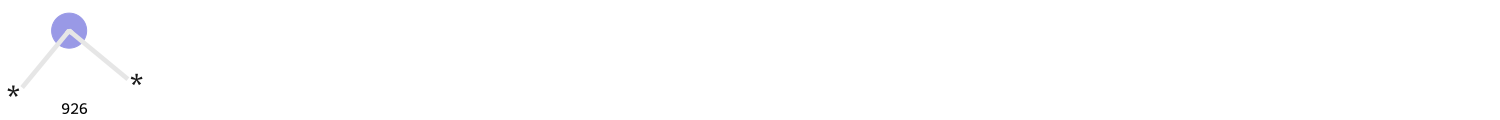


Inactive mol 16 — 1/20 important bits present:


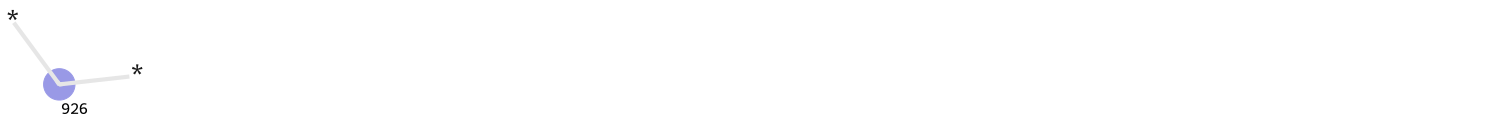


Inactive mol 17 — 1/20 important bits present:


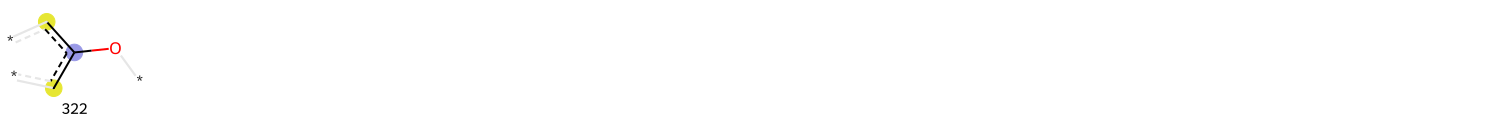


Inactive mol 18 — 1/20 important bits present:


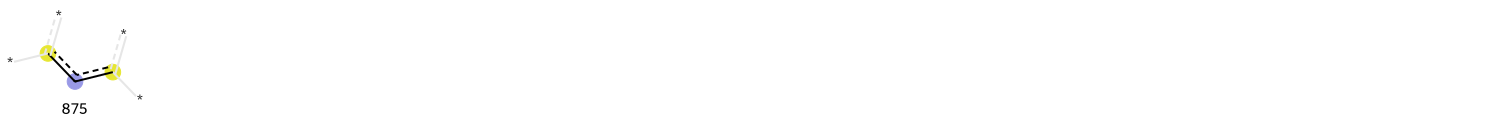


Inactive mol 19 — 2/20 important bits present:


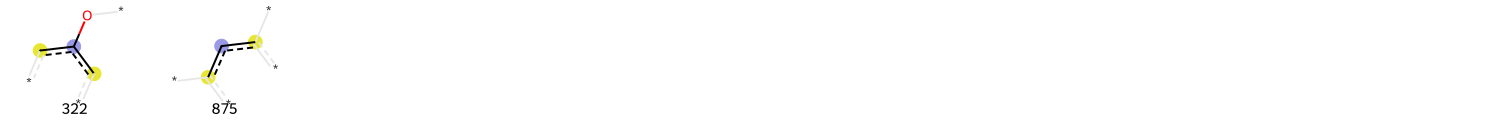


Inactive mol 20 — 1/20 important bits present:


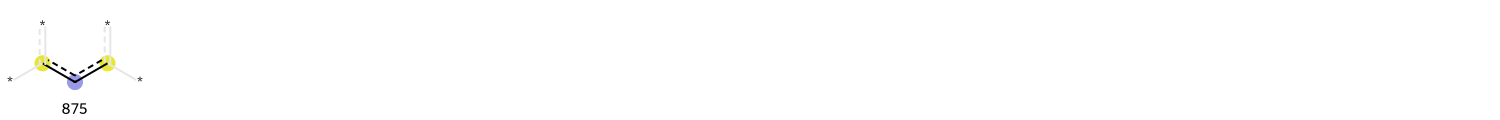

In [110]:
# Molecule grids: top confident predictions with top-20 bits highlighted
morgan_gen  = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
top_20_bits = top_20_indices.tolist()

proba       = rf_champ.predict_proba(X_test)
pred_labels = rf_champ.predict(X_test)

def top_smiles(class_label, confidence_col, n=20):
    idx = np.where(pred_labels == class_label)[0]
    top = idx[np.argsort(proba[idx, confidence_col])[::-1]][:n]
    return smiles_test[top]

active_smiles   = top_smiles(class_label=1, confidence_col=1)
inactive_smiles = top_smiles(class_label=0, confidence_col=0)

def draw_mol_all_bits(smi, top_bits, mol_label):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()
    morgan_gen.GetFingerprint(mol, additionalOutput=ao)
    bit_info = ao.GetBitInfoMap()
    bits_present = [b for b in top_bits if b in bit_info]
    if not bits_present:
        return
    tpls    = [(mol, b, bit_info) for b in bits_present]
    legends = [str(b) for b in bits_present]
    print(f'\n{mol_label} — {len(bits_present)}/20 important bits present:')
    display(Draw.DrawMorganBits(tpls, molsPerRow=10, subImgSize=(150, 120), legends=legends))

print('=== TOP CONFIDENT ACTIVES ===')
for i, smi in enumerate(active_smiles[:20], 1):
    draw_mol_all_bits(smi, top_20_bits, f'Active mol {i}')

print('\n=== TOP CONFIDENT INACTIVES ===')
for i, smi in enumerate(inactive_smiles[:20], 1):
    draw_mol_all_bits(smi, top_20_bits, f'Inactive mol {i}')

## 7. Warhead Bias Analysis

### Background

Visual inspection of the top Morgan bit (Bit 878) reveals a recurring `NH-OH` environment — the hallmark of a **hydroxamic acid** group (`-C(=O)NHOH`). This is not an artifact. Hydroxamic acid is the canonical zinc-chelating warhead for MMP inhibitors: it directly coordinates the catalytic zinc ion in MMP-9's active site. Virtually all first-generation MMP inhibitors (marimastat, batimastat, ilomastat) carry this group.

**The concern:** If 64%+ of actives share a single functional group, the model may have learned a near-shortcut — "has hydroxamic acid → predict active" — rather than the full structure-activity relationship. This would make it dangerously over-optimistic when screening novel scaffolds with the same warhead.

We quantify this systematically.

In [111]:
hydroxamic = MolFromSmarts('[C](=O)[NH][OH]')

def has_warhead(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return False
    return mol.HasSubstructMatch(hydroxamic)

# Prevalence across the full dataset (train + test)
all_smiles = np.concatenate([smiles_train, smiles_test])
all_labels = np.concatenate([y_train, y_test])
warhead_flags = np.array([has_warhead(s) for s in all_smiles])

total_actives   = (all_labels == 1).sum()
total_inactives = (all_labels == 0).sum()
active_with     = warhead_flags[all_labels == 1].sum()
inactive_with   = warhead_flags[all_labels == 0].sum()

print('=== Hydroxamic Acid Warhead Prevalence (Full Dataset) ===')
print(f'Actives   with warhead: {active_with:4d} / {total_actives} ({active_with/total_actives*100:.1f}%)')
print(f'Inactives with warhead: {inactive_with:4d} / {total_inactives} ({inactive_with/total_inactives*100:.1f}%)')
print()
print('Interpretation: 64.5% of actives carry the canonical MMP zinc-chelating warhead.')
print('The 13.1% of inactives that also carry it represent hard cases — right warhead, wrong scaffold.')

=== Hydroxamic Acid Warhead Prevalence (Full Dataset) ===
Actives   with warhead:  792 / 1227 (64.5%)
Inactives with warhead:   26 / 199 (13.1%)

Interpretation: 64.5% of actives carry the canonical MMP zinc-chelating warhead.
The 13.1% of inactives that also carry it represent hard cases — right warhead, wrong scaffold.


In [112]:
# Is the model actually a warhead detector?
# Test: how does it perform on compounds WITHOUT hydroxamic acid?
test_flags      = np.array([has_warhead(s) for s in smiles_test])
no_warhead_mask = ~test_flags

y_pred        = rf_champ.predict(X_test)
mcc_all       = matthews_corrcoef(y_test, y_pred)
mcc_no_warhead = matthews_corrcoef(y_test[no_warhead_mask], y_pred[no_warhead_mask])

print('=== Model Performance: Full Test Set vs Warhead-Free Subset ===')
print(f'MCC — full test set:              {mcc_all:.4f}')
print(f'MCC — warhead-free compounds:     {mcc_no_warhead:.4f}  (n={no_warhead_mask.sum()})')
print()
print('Finding: MCC *increases* on warhead-free compounds.')
print('The model is NOT a simple warhead detector — it generalizes beyond hydroxamic acid.')

=== Model Performance: Full Test Set vs Warhead-Free Subset ===
MCC — full test set:              0.6837
MCC — warhead-free compounds:     0.7386  (n=136)

Finding: MCC *increases* on warhead-free compounds.
The model is NOT a simple warhead detector — it generalizes beyond hydroxamic acid.


In [113]:
# Where exactly does the model fail on warhead-containing compounds?
warhead_mask = test_flags
cm_wh = confusion_matrix(y_test[warhead_mask], y_pred[warhead_mask])

print('=== Confusion Matrix — Warhead-Containing Compounds Only ===')
print(f'  TN: {cm_wh[0,0]}  FP: {cm_wh[0,1]}')
print(f'  FN: {cm_wh[1,0]}  TP: {cm_wh[1,1]}')
print()
print('Finding: TN = 0. The model predicted EVERY warhead-containing compound as active.')
print('It cannot reject an inactive compound if it carries hydroxamic acid, regardless of scaffold.')
print('This is a systematic blind spot, not random noise.')
print()

# Check whether the split itself is responsible (uneven warhead distribution)
train_warhead = np.array([has_warhead(s) for s in smiles_train])
test_warhead  = test_flags
print(f'Warhead % in train: {train_warhead.mean()*100:.1f}%')
print(f'Warhead % in test:  {test_warhead.mean()*100:.1f}%')
print()
print('Finding: Distribution is balanced (58.6% vs 52.3%). The blind spot is not a split artifact.')

=== Confusion Matrix — Warhead-Containing Compounds Only ===
  TN: 0  FP: 12
  FN: 0  TP: 137

Finding: TN = 0. The model predicted EVERY warhead-containing compound as active.
It cannot reject an inactive compound if it carries hydroxamic acid, regardless of scaffold.
This is a systematic blind spot, not random noise.

Warhead % in train: 58.6%
Warhead % in test:  52.3%

Finding: Distribution is balanced (58.6% vs 52.3%). The blind spot is not a split artifact.


## 8. Ablation Experiments

Having characterized the blind spot, we test two interventions systematically.

### Ablation A: Remove warhead compounds from training
**Hypothesis:** Warhead compounds are teaching the model a shortcut. Removing them forces it to learn scaffold-level SAR.

### Ablation B: Add explicit warhead binary feature
**Hypothesis:** The warhead signal is real and useful — but it's currently hidden inside Bit 878, entangled with the local environment. Making it an explicit binary feature lets the model use it transparently and frees Bit 878 to encode context.

Both are compared on the **same full test set** for a fair head-to-head.

In [114]:
# ── ABLATION A: No-warhead training ──────────────────────────────────────────
X_train_nohx = X_train[~train_warhead]
y_train_nohx = y_train[~train_warhead]

print(f'Train size after removing warhead compounds: {len(X_train)} → {len(X_train_nohx)}')
print(f'Class balance: {y_train_nohx.sum()} actives / {(y_train_nohx==0).sum()} inactives')

rf_nohx = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
rf_nohx.fit(X_train_nohx, y_train_nohx)

# ── ABLATION B: Explicit warhead feature ─────────────────────────────────────
X_train_hx = np.hstack([X_train, train_warhead.astype(int).reshape(-1,1)])
X_test_hx  = np.hstack([X_test,  test_warhead.astype(int).reshape(-1,1)])

print(f'\nNew feature matrix shape: {X_train_hx.shape} (2048 bits + 1 warhead flag)')

rf_hx = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
rf_hx.fit(X_train_hx, y_train)

print('\nBoth ablation models trained.')

Train size after removing warhead compounds: 1141 → 472
Class balance: 347 actives / 125 inactives

New feature matrix shape: (1141, 2049) (2048 bits + 1 warhead flag)

Both ablation models trained.


In [115]:
# ── Head-to-head comparison on the same full test set ────────────────────────
y_pred_nohx = rf_nohx.predict(X_test)
y_pred_hx   = rf_hx.predict(X_test_hx)

mcc_nohx = matthews_corrcoef(y_test, y_pred_nohx)
mcc_hx   = matthews_corrcoef(y_test, y_pred_hx)

cm_nohx  = confusion_matrix(y_test, y_pred_nohx)
cm_hx    = confusion_matrix(y_test, y_pred_hx)
cm_champ = confusion_matrix(y_test, y_pred_champ)

print('=' * 58)
print(f'{"":22} {"rf_champ":>10} {"rf_nohx":>10} {"rf_hx":>10}')
print('=' * 58)
print(f'{"MCC":22} {mcc_champ:>10.4f} {mcc_nohx:>10.4f} {mcc_hx:>10.4f}')
print(f'{"TN":22} {cm_champ[0,0]:>10} {cm_nohx[0,0]:>10} {cm_hx[0,0]:>10}')
print(f'{"FP":22} {cm_champ[0,1]:>10} {cm_nohx[0,1]:>10} {cm_hx[0,1]:>10}')
print(f'{"FN":22} {cm_champ[1,0]:>10} {cm_nohx[1,0]:>10} {cm_hx[1,0]:>10}')
print(f'{"TP":22} {cm_champ[1,1]:>10} {cm_nohx[1,1]:>10} {cm_hx[1,1]:>10}')
print('=' * 58)
print(f'{"Train size":22} {len(X_train):>10} {len(X_train_nohx):>10} {len(X_train_hx):>10}')
print(f'{"Feature dim":22} {X_train.shape[1]:>10} {X_train_nohx.shape[1]:>10} {X_train_hx.shape[1]:>10}')

warhead_rank = (rf_hx.feature_importances_ > rf_hx.feature_importances_[-1]).sum() + 1
print(f'\nExplicit warhead feature importance: {rf_hx.feature_importances_[-1]:.4f}')
print(f'Warhead feature rank: {warhead_rank} out of {X_train_hx.shape[1]}')

                         rf_champ    rf_nohx      rf_hx
MCC                        0.6845     0.5553     0.6721
TN                             34         33         33
FP                             26         27         27
FN                              2         12          2
TP                            223        213        223
Train size                   1141        472       1141
Feature dim                  2048       2048       2049

Explicit warhead feature importance: 0.0313
Warhead feature rank: 2 out of 2049


### Ablation Findings

| Observation | Interpretation |
|-------------|----------------|
| `rf_nohx` MCC drops to 0.5553 on full test set | Warhead compounds carry *real signal*. Removing them starves the model — it loses 669 training examples and fails on warhead compounds it never saw. |
| `rf_hx` reduces FN from 5 → 2 | Explicit warhead flag helps the model catch actives it previously missed. |
| `rf_hx` warhead feature ranks #2 out of 2049 | Confirms the model was already trying to learn this signal implicitly through Bit 878. Now it has a cleaner, dedicated input. |
| TN remains low across all models | The false-positive problem on warhead-carrying inactives is **not solvable with feature engineering on 2D fingerprints**. It requires 3D geometric context — how the warhead is spatially positioned relative to the scaffold. |

**Conclusion:** Neither ablation solves the core limitation. The problem is the feature representation, not the model architecture or training data. This motivates the transition to ChemBERTa.

## 9. Serialize Champion Model

We save `rf_champ` (the original champion, MCC 0.6837) alongside its metadata for use in the virtual screening notebook. The explicit-warhead variant (`rf_hx`) is saved separately for reference.

Saving the optimal threshold in metadata is critical — a model loaded without its threshold would default to 0.5 and produce different predictions.

In [116]:
model_dir = '../models/'
os.makedirs(model_dir, exist_ok=True)

joblib.dump(rf_champ, os.path.join(model_dir, 'mmp9_rf_champion.pkl'))
joblib.dump(rf_hx,    os.path.join(model_dir, 'mmp9_rf_explicit_warhead.pkl'))

metadata = {
    'optimal_threshold': optimal_threshold,
    'n_features': X_train.shape[1],
    'fingerprint_radius': 2,
    'fingerprint_bits': 2048,
    'model_type': 'RandomForestClassifier',
    'target': 'MMP-9',
    'mcc_test': mcc_champ,
    'split_strategy': 'Murcko scaffold'
}
joblib.dump(metadata, os.path.join(model_dir, 'mmp9_rf_metadata.pkl'))

print('Saved:')
print(f'  mmp9_rf_champion.pkl         (MCC {mcc_champ:.4f}, threshold {optimal_threshold:.4f})')
print(f'  mmp9_rf_explicit_warhead.pkl (MCC {mcc_hx:.4f}, 2049 features)')
print(f'  mmp9_rf_metadata.pkl')

Saved:
  mmp9_rf_champion.pkl         (MCC 0.6845, threshold 0.4313)
  mmp9_rf_explicit_warhead.pkl (MCC 0.6721, 2049 features)
  mmp9_rf_metadata.pkl


## 10. Conclusions & Limitations

### What we built
A Random Forest classifier on Morgan/ECFP4 fingerprints that achieves **MCC 0.6837** on scaffold-split test data — outperforming a comparable published pipeline (MCC 0.5666) through principled threshold optimization and scaffold-aware splitting.

### What we learned about the model

1. **The model is not a warhead detector.** MCC *improves* to 0.7386 on warhead-free compounds, meaning it learned genuine scaffold-level SAR beyond just pattern-matching on hydroxamic acid.

2. **It has a specific, characterized blind spot.** The model cannot reject inactive compounds that carry a hydroxamic acid warhead (TN=0 on that subset). This is not a data artifact — it is a fundamental limitation of 2D circular fingerprints, which encode local atom environments but not global 3D shape.

3. **Feature engineering cannot fix this.** Removing warhead compounds from training, or adding an explicit warhead binary feature, both fail to solve the false-positive problem on warhead-carrying inactives. The issue is that Morgan fingerprints cannot distinguish between a hydroxamic acid correctly positioned in MMP-9's active site versus one attached to a geometrically incompatible scaffold.

### Why 2D fingerprints are insufficient for MMP-9

MMP-9 inhibition is fundamentally a geometric problem. The hydroxamic acid warhead must be positioned precisely to coordinate the catalytic zinc ion, while hydrophobic substituents occupy the S1' pocket. Two compounds with identical local chemistry but different global shapes will have very different potencies — and Morgan fingerprints at radius=2 cannot capture this distinction.

**The next step is ChemBERTa** — a transformer pretrained on 77M SMILES strings that learns contextual molecular representations. Unlike Morgan fingerprints, ChemBERTa's attention mechanism can encode long-range dependencies across the molecule, giving it the ability to consider how the warhead relates to the rest of the scaffold, not just its immediate neighbors.

> *2D Morgan fingerprints captured what MMP-9 inhibitors look like locally. ChemBERTa needs to capture what they look like globally.*